# Machine Learning Methods

The machine learning section evaluates whether gender representation variables improve prediction of movie outcomes. The models are used for both prediction and comparison of feature groups.

The main tasks are:

1. Predict whether a movie receives a high IMDb rating.
2. Predict whether a movie is profitable.
3. Predict whether a movie has high popularity.
4. Predict IMDb rating as a continuous value in a regression check.

The modeling design compares baseline movie metadata with additional cast, crew, and Bechdel-related representation variables.

## 1. Setup and Data Loading

This section imports the required packages, applies the plotting configuration, and loads `cleaned_movie_dataset.csv`. The dataset includes movie metadata, outcome variables, and representation features used in the modeling tasks.

In [1]:
# Import packages for preprocessing, model training, evaluation, and plotting.
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    recall_score,
    r2_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Configure the shared Seaborn theme and color palette.
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "legend.title_fontsize": 10,
})
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# Load cleaned_movie_dataset.csv from the processed data folder.
DATA_PATH = Path("../data/processed/cleaned_movie_dataset.csv")
df = pd.read_csv(DATA_PATH)

required_columns = [
    "budget", "revenue", "log_budget", "log_revenue", "has_financial_data",
    "female_ratio_all_cast", "female_director", "female_crew_ratio",
    "imdbAverageRating", "popularity",
]
missing_required = [col for col in required_columns if col not in df.columns]
if missing_required:
    raise ValueError(f"The ML notebook must use cleaned_movie_dataset.csv. Missing columns: {missing_required}")

print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
df.head()

Dataset shape: 45,346 rows x 58 columns


,tmdb_id,imdb_id,movieId,title,year,release_decade,budget_raw,revenue_raw,budget,revenue,profit,roi,log_budget,log_revenue,popularity,runtime,vote_average,vote_count,movielens_avg_rating,movielens_rating_count,imdbAverageRating,numVotes,bechdelRating,bechdel_pass,genre1,genre2,genre3,original_language,production_country,main_production_company,female_ratio_all_cast,female_ratio_top3,female_ratio_top5,female_ratio_top10,female_lead,female_second_billed,female_director,female_writer,female_producer,female_executive_producer,female_editor,female_cinematographer,female_crew_ratio,female_creative_leadership_score,oscar_nomination_count,oscar_win_count,oscar_directing_nomination,oscar_directing_win,oscar_best_picture_nomination,oscar_best_picture_win,has_budget_data,has_revenue_data,has_financial_data,has_imdb_rating_data,has_bechdel_data,has_cast_representation_data,has_crew_representation_data,has_core_eda_data
0,862,tt0114709,1,Toy Story,1995,1990,30000000,"373,554,033.000","30,000,000.000","373,554,033.000","343,554,033.000",12.452,17.217,19.739,21.947,81.000,7.700,"5,415.000",3.888,"66,008.000",8.300,"1,071,627.000",1.000,0.000,Animation,Comedy,Family,en,United States of America,Pixar Animation Studios,0.250,0.000,0.000,0.222,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.121,0.167,4,1,0,0,0,0,1,1,1,1,1,1,1,1
1,8844,tt0113497,2,Jumanji,1995,1990,65000000,"262,797,249.000","65,000,000.000","262,797,249.000","197,797,249.000",4.043,17.990,19.387,17.016,104.000,6.900,"2,413.000",3.237,"26,060.000",7.100,"378,301.000",3.000,1.000,Adventure,Fantasy,Family,en,United States of America,TriStar Pictures,0.400,0.333,0.500,0.625,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0,0,0,0,0,0,1,1,1,1,1,1,1,1
2,15602,tt0113228,3,Grumpier Old Men,1995,1990,0,0.000,NaN,NaN,NaN,NaN,NaN,NaN,11.713,101.000,6.500,92.000,3.176,"15,497.000",6.600,"29,796.000",3.000,1.000,Romance,Comedy,NaN,en,United States of America,Warner Bros.,0.429,0.333,0.600,0.429,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0,0,0,0,0,0,0,0,0,1,1,1,1,1
3,31357,tt0114885,4,Waiting to Exhale,1995,1990,16000000,"81,452,156.000","16,000,000.000","81,452,156.000","65,452,156.000",5.091,16.588,18.216,3.859,127.000,6.100,34.000,2.876,"2,981.000",6.000,"12,237.000",2.000,0.000,Comedy,Drama,Romance,en,United States of America,Twentieth Century Fox Film Corporation,0.400,1.000,0.800,0.400,1.000,1.000,0.000,0.000,1.000,0.000,0.000,0.000,0.250,0.167,0,0,0,0,0,0,1,1,1,1,1,1,1,1
4,11862,tt0113041,5,Father of the Bride Part II,1995,1990,0,"76,578,911.000",NaN,"76,578,911.000",NaN,NaN,NaN,18.154,8.388,106.000,5.700,173.000,3.080,"15,258.000",NaN,NaN,NaN,NaN,Comedy,NaN,NaN,en,United States of America,Sandollar Productions,0.455,0.333,0.400,0.444,0.000,1.000,0.000,1.000,1.000,0.000,0.000,0.000,0.286,0.333,0,0,0,0,0,0,0,1,0,0,0,1,1,1


## 2. Modeling Design

Input variables are organized into feature groups before model fitting:

- **Controls only:** year, budget, runtime, genre, language, and country.
- **Controls + cast:** controls plus on-screen representation variables.
- **Controls + crew:** controls plus behind-camera representation variables.
- **Controls + cast + crew + Bechdel:** the full representation feature set.

This structure allows each task to compare models with and without representation variables.

In [2]:
# Create a copy of the cleaned dataset for feature engineering and modeling.
model_df = df.copy()

# Use financial columns where zero budget and revenue values have been converted to missing values.
# Create a binary indicator for budget availability.
model_df["budget_missing"] = model_df["budget"].isna().astype(int)

# Create log-transformed versions of skewed financial and vote-count variables.
model_df["log_budget"] = np.log1p(model_df["budget"])
model_df["log_revenue"] = np.log1p(model_df["revenue"])
model_df["log_numVotes"] = np.log1p(model_df["numVotes"].clip(lower=0))

# Define control features based on movie metadata and production information.
control_numeric = ["year", "release_decade", "log_budget", "budget_missing", "runtime"]
control_categorical = ["genre1", "genre2", "genre3", "original_language", "production_country"]

# Define on-screen cast representation features.
cast_features = [
    "female_ratio_all_cast",
    "female_ratio_top3",
    "female_ratio_top5",
    "female_ratio_top10",
    "female_lead",
    "female_second_billed",
]

# Define behind-camera crew representation features.
crew_features = [
    "female_director",
    "female_writer",
    "female_producer",
    "female_executive_producer",
    "female_editor",
    "female_cinematographer",
    "female_crew_ratio",
    "female_creative_leadership_score",
]

# Define Bechdel-related representation features.
bechdel_features = ["bechdel_pass", "bechdelRating"]

# Build feature groups used in the model comparison tasks.
feature_groups = {
    "Controls only": control_numeric + control_categorical,
    "Controls + cast": control_numeric + control_categorical + cast_features,
    "Controls + crew": control_numeric + control_categorical + crew_features,
    "Controls + cast + crew + Bechdel": (
        control_numeric + control_categorical + cast_features + crew_features + bechdel_features
    ),
}

# Count the pre-encoding columns in each feature group.
feature_group_summary = pd.DataFrame({
    "Feature group": list(feature_groups.keys()),
    "Number of input columns before encoding": [len(cols) for cols in feature_groups.values()],
})
display(feature_group_summary)

,Feature group,Number of input columns before encoding
0,Controls only,10
1,Controls + cast,16
2,Controls + crew,18
3,Controls + cast + crew + Bechdel,26


## 3. Target Availability

The target variables have different amounts of usable data. Popularity is available for most movies, while IMDb rating and profitability require more complete external or financial information. This section summarizes the available sample size for each modeling task.

,Target / subset,Rows
2,Positive budget and revenue,5375
0,IMDb rating available,7709
1,Popularity available,45346


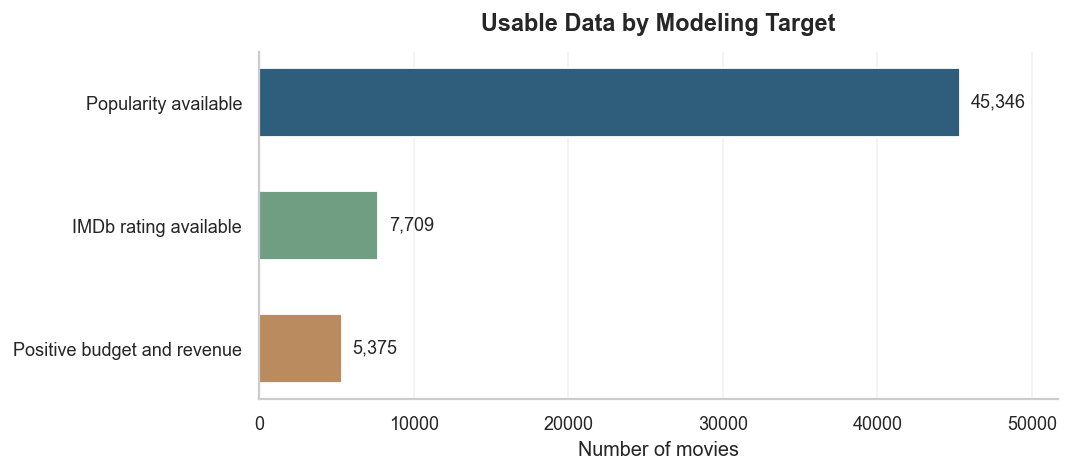

In [3]:
# Count usable observations for each modeling target.
target_availability = pd.DataFrame({
    "Target / subset": [
        "IMDb rating available",
        "Popularity available",
        "Positive budget and revenue",
    ],
    "Rows": [
        model_df["imdbAverageRating"].notna().sum(),
        model_df["popularity"].notna().sum(),
        model_df["has_financial_data"].sum(),
    ],
}).sort_values("Rows")

display(target_availability)

# Plot the available sample size for each modeling target.
fig, ax = plt.subplots(figsize=(8.4, 3.8))
colors = ["#B98B5F", "#6F9E82", "#2F5D7C"]
ax.barh(target_availability["Target / subset"], target_availability["Rows"], color=colors, height=0.56)
ax.set_title("Usable Data by Modeling Target", pad=12)
ax.set_xlabel("Number of movies")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.25)
ax.grid(axis="y", visible=False)
ax.set_xlim(0, target_availability["Rows"].max() * 1.14)

# Add sample-size labels to the bar chart.
for y, value in enumerate(target_availability["Rows"]):
    ax.text(value + target_availability["Rows"].max() * 0.015, y, f"{value:,.0f}", va="center", fontsize=10)

plt.tight_layout()
plt.show()

## 4. Reusable Modeling Functions

This section defines shared preprocessing, training, evaluation, and plotting functions. The same pipeline structure is then reused across the classification and regression tasks.

In [4]:
# Set OneHotEncoder arguments according to the installed scikit-learn version.
def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", min_frequency=25, sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", min_frequency=25, sparse=False)


def build_preprocessor(features):
    """Create preprocessing steps for the current feature group."""
    numeric_candidates = set(control_numeric + cast_features + crew_features + bechdel_features)
    numeric_features = [feature for feature in features if feature in numeric_candidates]
    categorical_features = [feature for feature in features if feature in control_categorical]

    # Define numeric preprocessing with median imputation and scaling.
    numeric_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("scaler", StandardScaler()),
    ])

    # Define categorical preprocessing with imputation and one-hot encoding.
    categorical_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_one_hot_encoder()),
    ])

    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_features),
            ("cat", categorical_pipeline, categorical_features),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )


def classification_models():
    """Return the two classification models used in the comparison."""
    return {
        "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
        "Random Forest": RandomForestClassifier(
            n_estimators=140,
            max_depth=10,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        ),
    }


def regression_models():
    """Return the regression models used for the rating check."""
    return {
        "Linear Regression": LinearRegression(),
        "Random Forest Regressor": RandomForestRegressor(
            n_estimators=140,
            max_depth=10,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1,
        ),
    }


def evaluate_classification(data, target, task_name):
    """Run the classification comparison for one target."""
    rows = []
    fitted = {}
    y = data[target].astype(int)

    print(f"{task_name}")
    print(f"Rows used: {len(data):,}")
    print("Class distribution:")
    print(y.value_counts().sort_index())

    for group_name, features in feature_groups.items():
        available_features = [feature for feature in features if feature in data.columns]
        X = data[available_features]

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.25, random_state=42, stratify=y
        )

        for model_name, model in classification_models().items():
            pipeline = Pipeline(steps=[
                ("preprocess", build_preprocessor(available_features)),
                ("model", model),
            ])
            pipeline.fit(X_train, y_train)
            y_pred = pipeline.predict(X_test)
            y_score = pipeline.predict_proba(X_test)[:, 1]

            rows.append({
                "task": task_name,
                "feature_group": group_name,
                "model": model_name,
                "accuracy": accuracy_score(y_test, y_pred),
                "precision": precision_score(y_test, y_pred, zero_division=0),
                "recall": recall_score(y_test, y_pred, zero_division=0),
                "f1": f1_score(y_test, y_pred, zero_division=0),
                "roc_auc": roc_auc_score(y_test, y_score),
            })
            fitted[(group_name, model_name)] = {
                "pipeline": pipeline,
                "X_test": X_test,
                "y_test": y_test,
                "y_pred": y_pred,
            }

    results = pd.DataFrame(rows).sort_values(["roc_auc", "f1"], ascending=False)
    return results, fitted


def evaluate_regression(data, target, task_name):
    """Run the same comparison for a continuous target."""
    rows = []
    fitted = {}
    y = data[target].astype(float)

    print(f"{task_name}")
    print(f"Rows used: {len(data):,}")

    for group_name, features in feature_groups.items():
        available_features = [feature for feature in features if feature in data.columns]
        X = data[available_features]

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.25, random_state=42
        )

        for model_name, model in regression_models().items():
            pipeline = Pipeline(steps=[
                ("preprocess", build_preprocessor(available_features)),
                ("model", model),
            ])
            pipeline.fit(X_train, y_train)
            y_pred = pipeline.predict(X_test)

            rows.append({
                "task": task_name,
                "feature_group": group_name,
                "model": model_name,
                "mae": mean_absolute_error(y_test, y_pred),
                "rmse": np.sqrt(mean_squared_error(y_test, y_pred)),
                "r2": r2_score(y_test, y_pred),
            })
            fitted[(group_name, model_name)] = {
                "pipeline": pipeline,
                "X_test": X_test,
                "y_test": y_test,
                "y_pred": y_pred,
            }

    results = pd.DataFrame(rows).sort_values(["r2", "rmse"], ascending=[False, True])
    return results, fitted

In [5]:
# Define helper functions for model comparison plots and interpretation charts.
MODEL_COLORS = {
    "Logistic Regression": "#2F5D7C",
    "Random Forest": "#C08552",
    "Linear Regression": "#2F5D7C",
    "Random Forest Regressor": "#C08552",
}

CATEGORY_COLORS = {
    "Control": "#5B6770",
    "Cast": "#7A9E7E",
    "Crew": "#2F5D7C",
    "Bechdel": "#C08552",
}


def clean_group_label(label):
    labels = {
        "Controls only": "Controls only",
        "Controls + cast": "Controls + cast",
        "Controls + crew": "Controls + crew",
        "Controls + cast + crew + Bechdel": "Controls + cast + crew\n+ Bechdel",
    }
    return labels.get(label, label)


def feature_category(feature):
    if feature in cast_features:
        return "Cast"
    if feature in crew_features:
        return "Crew"
    if feature in bechdel_features:
        return "Bechdel"
    return "Control"


def pretty_feature_name(feature):
    names = {
        "log_budget": "budget (log)",
        "budget_missing": "budget missing",
        "female_ratio_all_cast": "female ratio, full cast",
        "female_ratio_top3": "female ratio, top 3 cast",
        "female_ratio_top5": "female ratio, top 5 cast",
        "female_ratio_top10": "female ratio, top 10 cast",
        "female_lead": "female lead",
        "female_second_billed": "female second-billed",
        "female_director": "female director",
        "female_writer": "female writer",
        "female_producer": "female producer",
        "female_executive_producer": "female executive producer",
        "female_editor": "female editor",
        "female_cinematographer": "female cinematographer",
        "female_crew_ratio": "female crew ratio",
        "female_creative_leadership_score": "female creative leadership",
        "bechdel_pass": "Bechdel pass",
        "bechdelRating": "Bechdel rating",
        "release_decade": "release decade",
        "original_language": "original language",
        "production_country": "production country",
    }
    return names.get(feature, feature.replace("_", " "))


def add_value_labels(ax, x_offset=0.004):
    # Add metric labels to model comparison bars.
    xmax = ax.get_xlim()[1]
    for collection in ax.collections:
        offsets = collection.get_offsets()
        for x, y in offsets:
            if np.isfinite(x) and np.isfinite(y):
                ax.text(min(x + x_offset, xmax), y, f"{x:.3f}", va="center", fontsize=9, color="#333333")


def plot_metric_dotplot(results, title, metric="roc_auc", xlabel="ROC-AUC"):
    plot_data = results.copy()
    plot_data["feature_group_label"] = plot_data["feature_group"].map(clean_group_label)

    # Apply a fixed feature-group order in comparison plots.
    ordered_groups = [clean_group_label(group) for group in feature_groups.keys()]
    model_order = list(plot_data["model"].drop_duplicates())
    y_base = np.arange(len(ordered_groups))
    bar_height = 0.34 if len(model_order) == 2 else 0.22
    offsets = np.linspace(-bar_height / 2, bar_height / 2, len(model_order))

    fig, ax = plt.subplots(figsize=(10.8, 5.0))

    for offset, model_name in zip(offsets, model_order):
        model_data = (
            plot_data[plot_data["model"] == model_name]
            .set_index("feature_group_label")
            .reindex(ordered_groups)
        )
        values = model_data[metric].values
        positions = y_base + offset

        ax.barh(
            positions,
            values,
            height=bar_height,
            color=MODEL_COLORS.get(model_name, "#555555"),
            label=model_name,
            alpha=0.95,
        )

        for x, y in zip(values, positions):
            if np.isfinite(x):
                ax.text(
                    x + (0.004 if metric != "r2" else 0.006),
                    y,
                    f"{x:.3f}",
                    va="center",
                    fontsize=9,
                    color="#333333",
                )

    lower = max(0, plot_data[metric].min() - 0.035)
    upper = min(1.0, plot_data[metric].max() + 0.065) if metric != "r2" else plot_data[metric].max() + 0.065
    ax.set_xlim(lower, upper)
    ax.set_yticks(y_base)
    ax.set_yticklabels(ordered_groups)
    ax.invert_yaxis()
    ax.set_title(title, pad=12)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("")
    ax.grid(axis="x", alpha=0.25)
    ax.grid(axis="y", visible=False)

    ax.legend(
        title="Model",
        frameon=False,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0,
    )

    plt.tight_layout(rect=[0, 0, 0.82, 1])
    plt.show()

def plot_classification_results(results, title):
    plot_metric_dotplot(results, title, metric="roc_auc", xlabel="ROC-AUC")


def plot_best_confusion_matrix(results, fitted, task_name, labels):
    # Select the highest-scoring model for the confusion matrix.
    best = results.sort_values(["roc_auc", "f1"], ascending=False).iloc[0]
    key = (best["feature_group"], best["model"])
    model_info = fitted[key]
    cm = confusion_matrix(model_info["y_test"], model_info["y_pred"])
    cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100
    annotations = np.array([
        [f"{cm[i, j]:,}\n{cm_percent[i, j]:.1f}%" for j in range(cm.shape[1])]
        for i in range(cm.shape[0])
    ])

    print(f"Best model: {best['model']}")
    print(f"Best feature group: {best['feature_group']}")
    print(f"ROC-AUC: {best['roc_auc']:.3f} | F1: {best['f1']:.3f}")

    fig, ax = plt.subplots(figsize=(5.2, 4.6))
    sns.heatmap(
        cm_percent,
        annot=annotations,
        fmt="",
        cmap=sns.light_palette("#2F5D7C", as_cmap=True),
        cbar=False,
        xticklabels=labels,
        yticklabels=labels,
        linewidths=1.2,
        linecolor="white",
        square=True,
        ax=ax,
    )
    ax.set_title(f"{task_name}: Confusion Matrix", pad=12)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("Actual label")
    ax.tick_params(axis="x", rotation=0)
    ax.tick_params(axis="y", rotation=0)
    plt.tight_layout()
    plt.show()


def plot_permutation_importance(results, fitted, title, scoring="roc_auc", top_n=10):
    # Calculate permutation importance for the selected model.
    best = results.sort_values(["roc_auc", "f1"], ascending=False).iloc[0]
    key = (best["feature_group"], best["model"])
    model_info = fitted[key]

    importance = permutation_importance(
        model_info["pipeline"],
        model_info["X_test"],
        model_info["y_test"],
        scoring=scoring,
        n_repeats=3,
        random_state=42,
        n_jobs=-1,
    )
    importance_df = pd.DataFrame({
        "feature": model_info["X_test"].columns,
        "importance": importance.importances_mean,
        "std": importance.importances_std,
    }).sort_values("importance", ascending=False)
    importance_df["category"] = importance_df["feature"].map(feature_category)
    importance_df["feature_label"] = importance_df["feature"].map(pretty_feature_name)

    top_features = importance_df.head(top_n).sort_values("importance", ascending=True)
    display(importance_df.head(top_n))

    fig, ax = plt.subplots(figsize=(9.2, 5.2))
    colors = top_features["category"].map(CATEGORY_COLORS)
    ax.barh(top_features["feature_label"], top_features["importance"], color=colors, height=0.58)
    ax.set_title(title, pad=12)
    ax.set_xlabel("Mean decrease in model score")
    ax.set_ylabel("")
    ax.grid(axis="x", alpha=0.25)
    ax.grid(axis="y", visible=False)
    ax.set_xlim(0, max(top_features["importance"].max() * 1.18, 0.01))

    for y, value in enumerate(top_features["importance"]):
        ax.text(value + ax.get_xlim()[1] * 0.015, y, f"{value:.3f}", va="center", fontsize=9)

    used_categories = [cat for cat in CATEGORY_COLORS if cat in top_features["category"].values]
    handles = [plt.Line2D([0], [0], marker="s", linestyle="", color=CATEGORY_COLORS[cat], markersize=9) for cat in used_categories]
    ax.legend(handles, used_categories, title="Feature type", frameon=False, loc="lower right")

    plt.tight_layout()
    plt.show()
    return importance_df


def best_vs_baseline(results, metric="roc_auc"):
    # Calculate metric gain relative to the controls-only baseline.
    baseline = (
        results[results["feature_group"] == "Controls only"]
        .sort_values([metric, "f1"], ascending=False)
        .iloc[0]
    )
    best = results.sort_values([metric, "f1"], ascending=False).iloc[0]
    return {
        "Baseline model": baseline["model"],
        "Baseline score": baseline[metric],
        "Best model": best["model"],
        "Best feature group": best["feature_group"],
        "Best score": best[metric],
        "Gain over baseline": best[metric] - baseline[metric],
    }

## 5. Task 1: Predict High IMDb Rating

IMDb rating is converted into a binary classification target using the median rating as the cutoff. Movies above the median are labeled as high-rated.

In [6]:
# Create a binary high IMDb rating target using the median cutoff.
imdb_df = model_df[model_df["imdbAverageRating"].notna()].copy()
imdb_threshold = imdb_df["imdbAverageRating"].median()
imdb_df["high_imdb_rating"] = (imdb_df["imdbAverageRating"] >= imdb_threshold).astype(int)

# Train classification models for each feature group.
imdb_results, imdb_models = evaluate_classification(
    imdb_df,
    target="high_imdb_rating",
    task_name=f"High IMDb rating, threshold >= {imdb_threshold:.2f}",
)

# Display classification metrics for all model and feature-group combinations.
display(imdb_results)

High IMDb rating, threshold >= 6.70
Rows used: 7,709
Class distribution:
high_imdb_rating
0    3570
1    4139
Name: count, dtype: int64


,task,feature_group,model,accuracy,precision,recall,f1,roc_auc
1,"High IMDb rating, threshold >= 6.70",Controls only,Random Forest,0.739,0.784,0.709,0.745,0.816
5,"High IMDb rating, threshold >= 6.70",Controls + crew,Random Forest,0.738,0.778,0.716,0.745,0.814
6,"High IMDb rating, threshold >= 6.70",Controls + cast + crew + Bechdel,Logistic Regression,0.735,0.778,0.710,0.742,0.814
7,"High IMDb rating, threshold >= 6.70",Controls + cast + crew + Bechdel,Random Forest,0.738,0.774,0.724,0.748,0.812
2,"High IMDb rating, threshold >= 6.70",Controls + cast,Logistic Regression,0.728,0.769,0.704,0.735,0.812
3,"High IMDb rating, threshold >= 6.70",Controls + cast,Random Forest,0.728,0.763,0.714,0.738,0.811
4,"High IMDb rating, threshold >= 6.70",Controls + crew,Logistic Regression,0.733,0.779,0.703,0.739,0.810
0,"High IMDb rating, threshold >= 6.70",Controls only,Logistic Regression,0.721,0.768,0.689,0.726,0.808


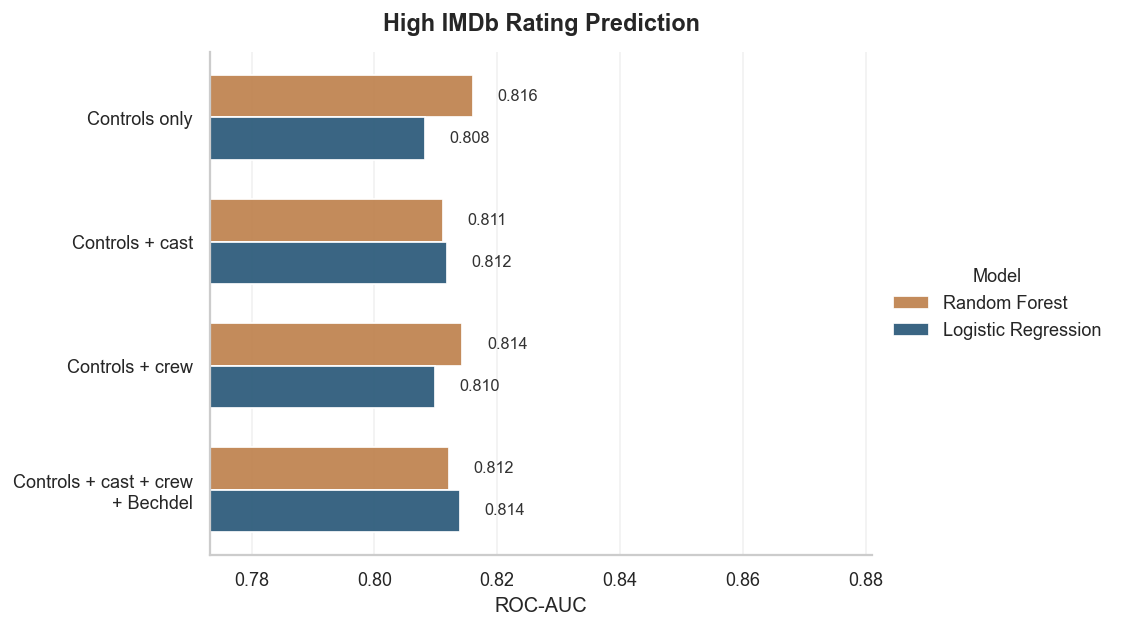

Best model: Random Forest
Best feature group: Controls only
ROC-AUC: 0.816 | F1: 0.745


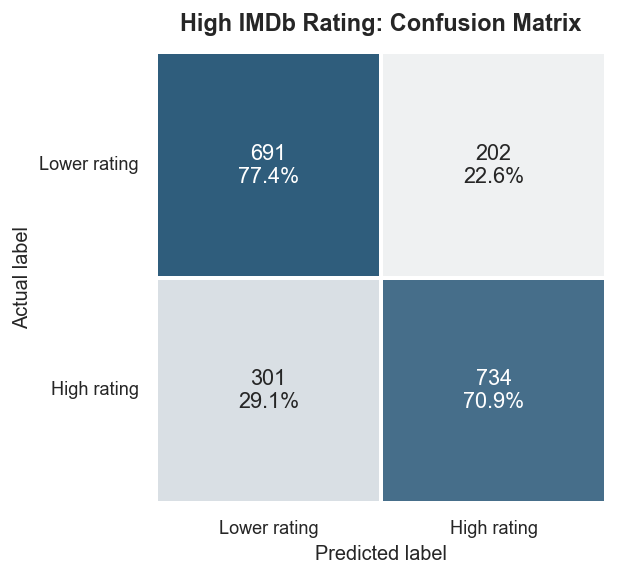

,feature,importance,std,category,feature_label
4,runtime,0.082,0.004,Control,runtime
5,genre1,0.056,0.003,Control,genre1
0,year,0.023,0.004,Control,year
8,original_language,0.023,0.004,Control,original language
1,release_decade,0.018,0.004,Control,release decade
6,genre2,0.014,0.000,Control,genre2
2,log_budget,0.011,0.001,Control,budget (log)
9,production_country,0.007,0.001,Control,production country
7,genre3,0.002,0.000,Control,genre3
3,budget_missing,0.002,0.000,Control,budget missing


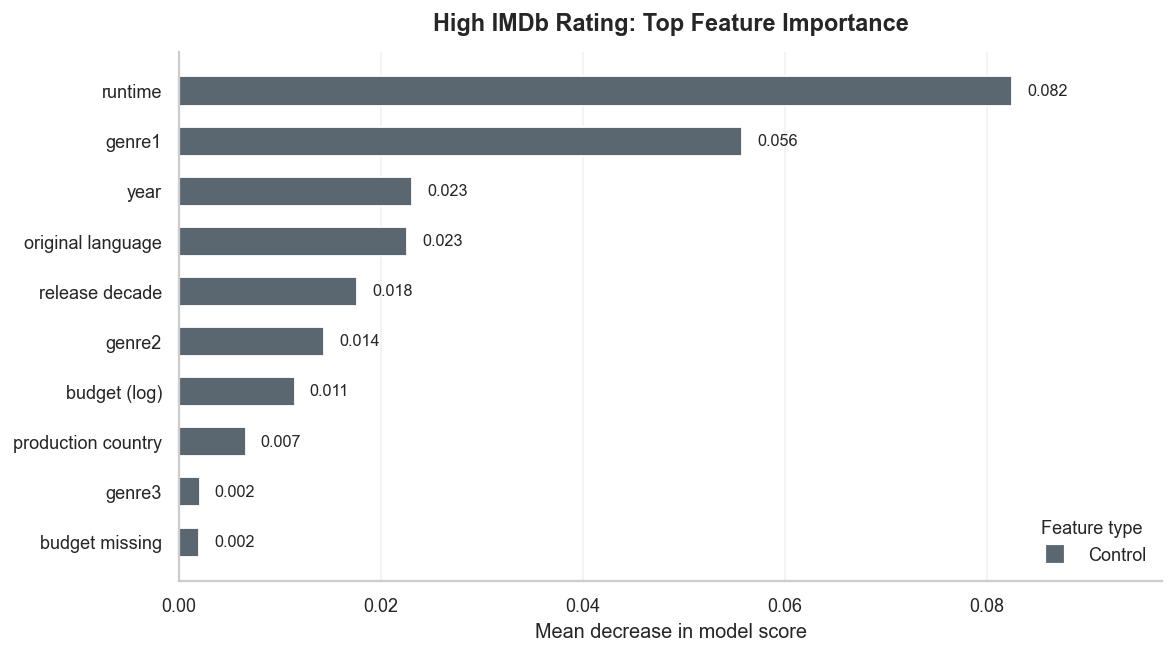

In [7]:
# Plot model comparison, confusion matrix, and permutation importance for IMDb rating.
plot_classification_results(imdb_results, "High IMDb Rating Prediction")
plot_best_confusion_matrix(
    imdb_results,
    imdb_models,
    task_name="High IMDb Rating",
    labels=["Lower rating", "High rating"],
)
imdb_importance = plot_permutation_importance(
    imdb_results,
    imdb_models,
    "High IMDb Rating: Top Feature Importance",
)

## 6. Task 2: Predict Profitability

Profitability is tested only on movies with valid budget and revenue data. A movie is labeled profitable when revenue is greater than budget. Revenue-derived variables are excluded from the input features for this task.

In [8]:
# Filter the dataset to movies with valid budget and revenue data for profitability modeling.
profit_df = model_df[model_df["has_financial_data"].eq(1)].copy()
profit_df["profitable"] = (profit_df["revenue"] > profit_df["budget"]).astype(int)

# Train profitability classifiers after excluding revenue-derived input features.
profit_results, profit_models = evaluate_classification(
    profit_df,
    target="profitable",
    task_name="Profitability, revenue > budget",
)

# Display profitability metrics for all model and feature-group combinations.
display(profit_results)

Profitability, revenue > budget
Rows used: 5,375
Class distribution:
profitable
0    1623
1    3752
Name: count, dtype: int64


,task,feature_group,model,accuracy,precision,recall,f1,roc_auc
7,"Profitability, revenue > budget",Controls + cast + crew + Bechdel,Random Forest,0.717,0.809,0.777,0.793,0.744
6,"Profitability, revenue > budget",Controls + cast + crew + Bechdel,Logistic Regression,0.670,0.812,0.687,0.744,0.713
5,"Profitability, revenue > budget",Controls + crew,Random Forest,0.617,0.821,0.577,0.678,0.696
1,"Profitability, revenue > budget",Controls only,Random Forest,0.615,0.824,0.569,0.673,0.690
3,"Profitability, revenue > budget",Controls + cast,Random Forest,0.617,0.825,0.572,0.676,0.688
0,"Profitability, revenue > budget",Controls only,Logistic Regression,0.592,0.776,0.584,0.667,0.635
4,"Profitability, revenue > budget",Controls + crew,Logistic Regression,0.586,0.769,0.582,0.663,0.634
2,"Profitability, revenue > budget",Controls + cast,Logistic Regression,0.583,0.767,0.579,0.660,0.622


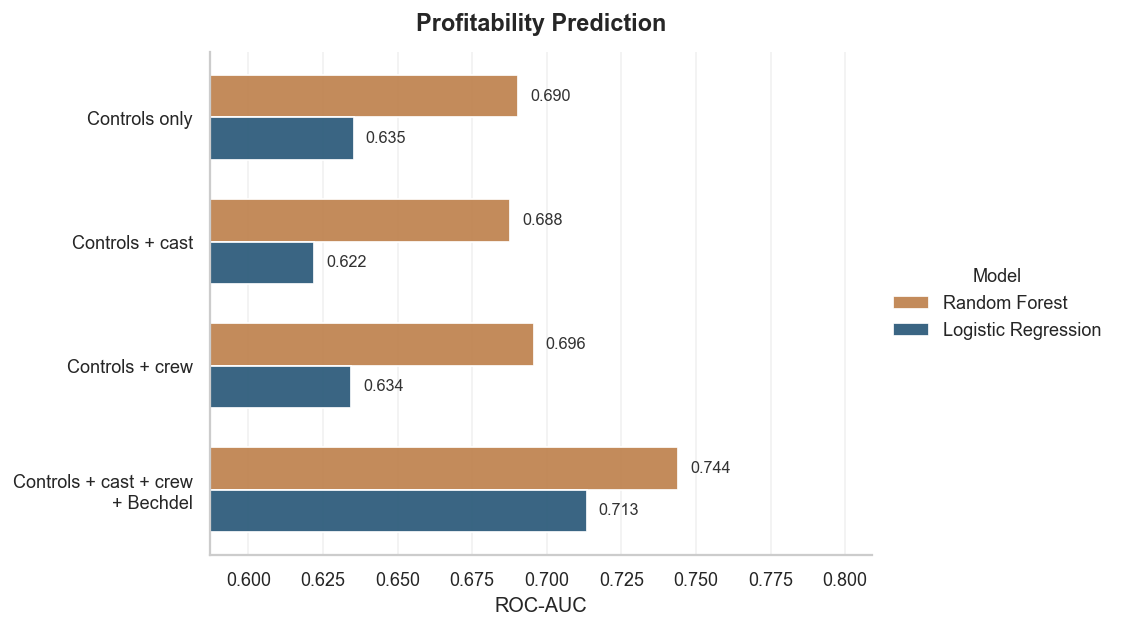

Best model: Random Forest
Best feature group: Controls + cast + crew + Bechdel
ROC-AUC: 0.744 | F1: 0.793


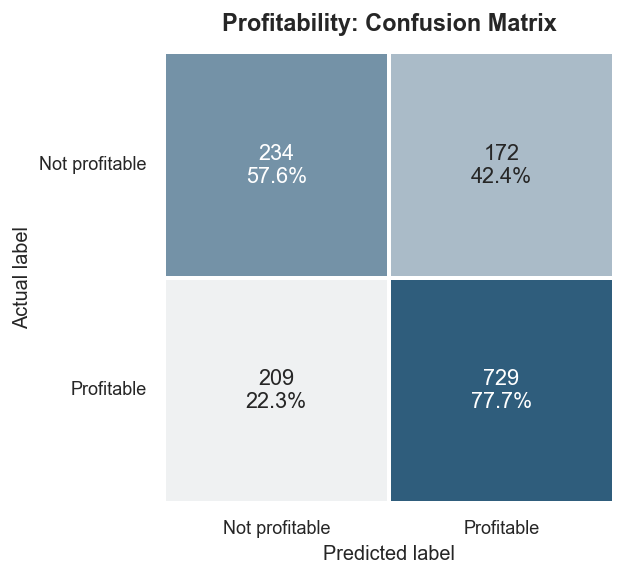

,feature,importance,std,category,feature_label
25,bechdelRating,0.045,0.001,Bechdel,Bechdel rating
2,log_budget,0.018,0.010,Control,budget (log)
0,year,0.018,0.005,Control,year
24,bechdel_pass,0.014,0.002,Bechdel,Bechdel pass
9,production_country,0.014,0.001,Control,production country
1,release_decade,0.013,0.004,Control,release decade
5,genre1,0.010,0.004,Control,genre1
4,runtime,0.006,0.001,Control,runtime
8,original_language,0.005,0.001,Control,original language
22,female_crew_ratio,0.003,0.001,Crew,female crew ratio


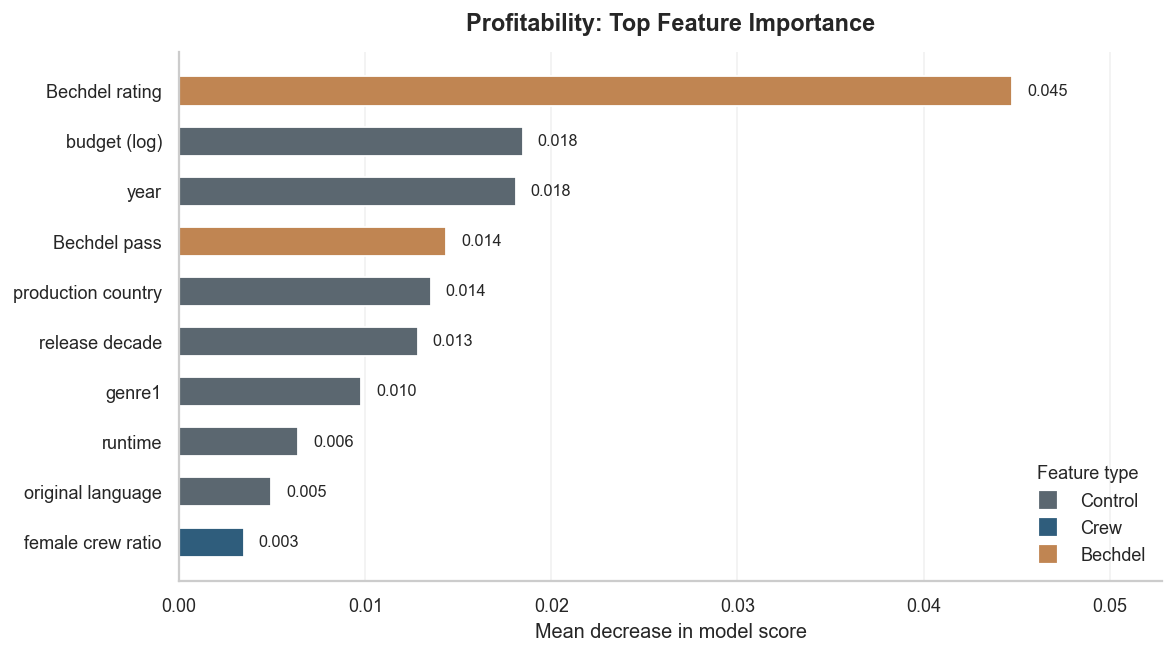

In [9]:
# Plot model comparison, confusion matrix, and permutation importance for profitability.
plot_classification_results(profit_results, "Profitability Prediction")
plot_best_confusion_matrix(
    profit_results,
    profit_models,
    task_name="Profitability",
    labels=["Not profitable", "Profitable"],
)
profit_importance = plot_permutation_importance(
    profit_results,
    profit_models,
    "Profitability: Top Feature Importance",
)

## 7. Task 3: Predict High Popularity

Popularity is available for most movies in the dataset. A median split is used to create a balanced binary target for high popularity.

In [10]:
# Create a binary high popularity target from the popularity variable.
popularity_df = model_df[model_df["popularity"].notna()].copy()
popularity_threshold = popularity_df["popularity"].median()
popularity_df["high_popularity"] = (popularity_df["popularity"] >= popularity_threshold).astype(int)

# Apply a median cutoff to define high and low popularity classes.
popularity_results, popularity_models = evaluate_classification(
    popularity_df,
    target="high_popularity",
    task_name=f"High popularity, threshold >= {popularity_threshold:.2f}",
)

# Display popularity metrics for all model and feature-group combinations.
display(popularity_results)

High popularity, threshold >= 1.13
Rows used: 45,346
Class distribution:
high_popularity
0    22673
1    22673
Name: count, dtype: int64


,task,feature_group,model,accuracy,precision,recall,f1,roc_auc
6,"High popularity, threshold >= 1.13",Controls + cast + crew + Bechdel,Logistic Regression,0.754,0.769,0.727,0.748,0.845
7,"High popularity, threshold >= 1.13",Controls + cast + crew + Bechdel,Random Forest,0.752,0.803,0.668,0.729,0.842
4,"High popularity, threshold >= 1.13",Controls + crew,Logistic Regression,0.735,0.744,0.717,0.730,0.820
5,"High popularity, threshold >= 1.13",Controls + crew,Random Forest,0.731,0.783,0.640,0.705,0.818
3,"High popularity, threshold >= 1.13",Controls + cast,Random Forest,0.730,0.734,0.722,0.728,0.814
2,"High popularity, threshold >= 1.13",Controls + cast,Logistic Regression,0.734,0.742,0.719,0.730,0.814
0,"High popularity, threshold >= 1.13",Controls only,Logistic Regression,0.722,0.736,0.692,0.713,0.799
1,"High popularity, threshold >= 1.13",Controls only,Random Forest,0.711,0.758,0.620,0.682,0.795


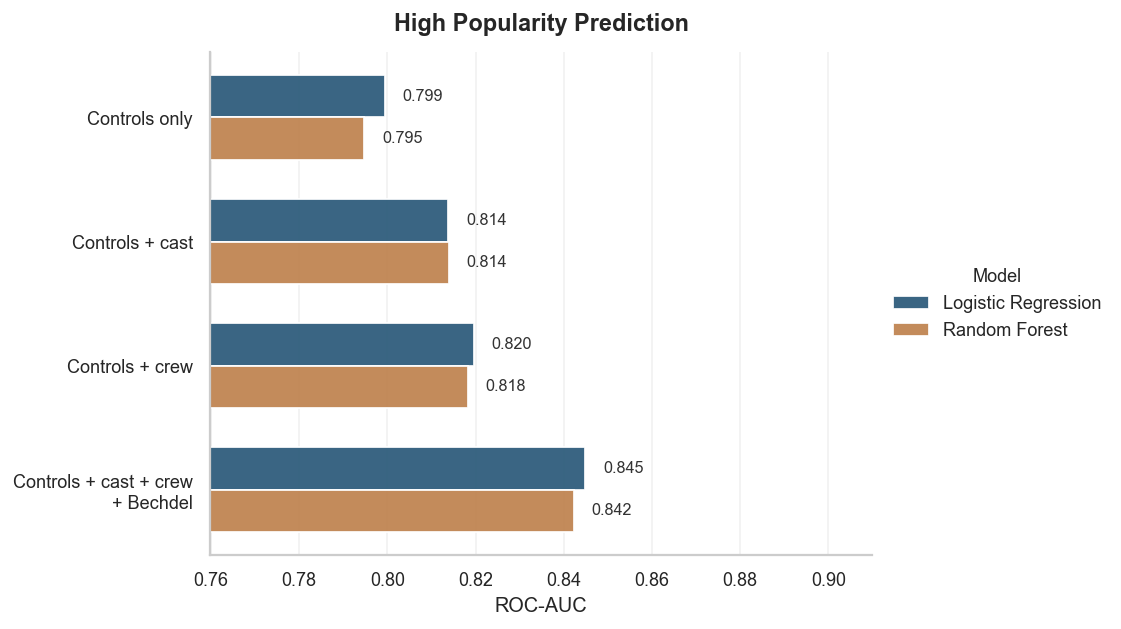

Best model: Logistic Regression
Best feature group: Controls + cast + crew + Bechdel
ROC-AUC: 0.845 | F1: 0.748


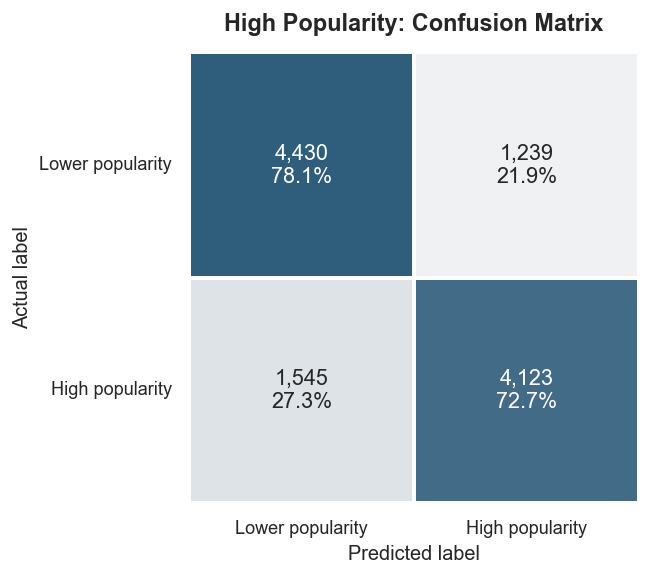

,feature,importance,std,category,feature_label
0,year,0.054,0.002,Control,year
22,female_crew_ratio,0.020,0.001,Crew,female crew ratio
10,female_ratio_all_cast,0.016,0.000,Cast,"female ratio, full cast"
5,genre1,0.013,0.000,Control,genre1
25,bechdelRating,0.013,0.001,Bechdel,Bechdel rating
9,production_country,0.012,0.001,Control,production country
24,bechdel_pass,0.011,0.001,Bechdel,Bechdel pass
4,runtime,0.010,0.000,Control,runtime
2,log_budget,0.010,0.001,Control,budget (log)
6,genre2,0.009,0.001,Control,genre2


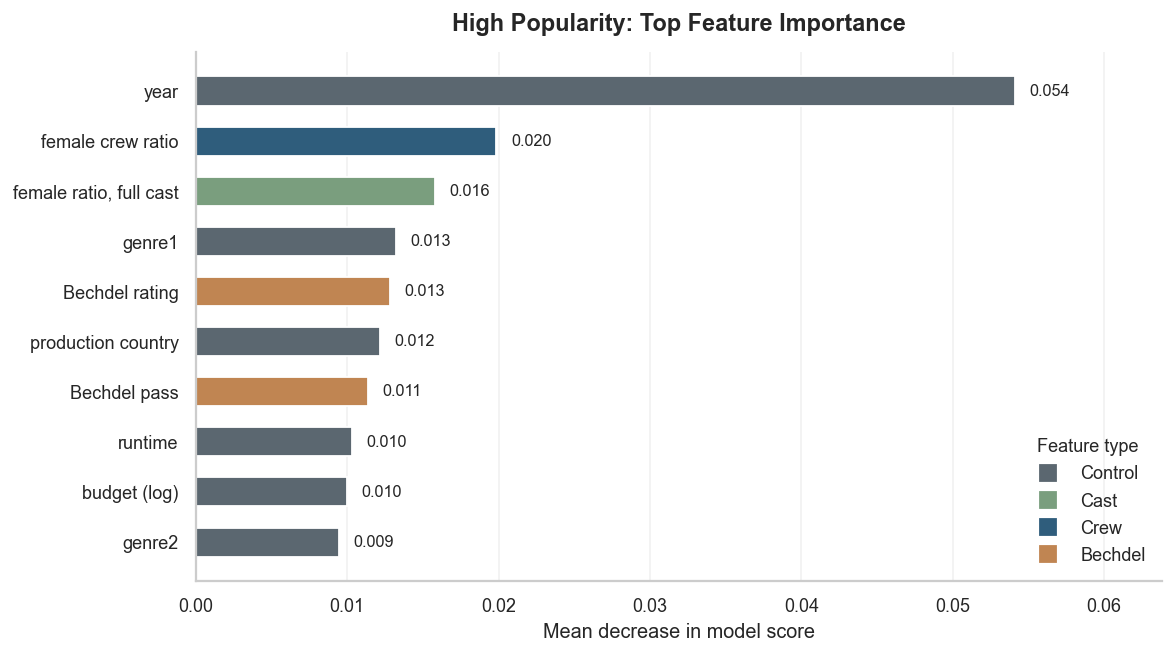

In [11]:
# Plot model comparison, confusion matrix, and permutation importance for popularity.
plot_classification_results(popularity_results, "High Popularity Prediction")
plot_best_confusion_matrix(
    popularity_results,
    popularity_models,
    task_name="High Popularity",
    labels=["Lower popularity", "High popularity"],
)
popularity_importance = plot_permutation_importance(
    popularity_results,
    popularity_models,
    "High Popularity: Top Feature Importance",
)

## 8. Regression Check: Predict IMDb Rating

This regression task predicts IMDb rating as a continuous outcome. It provides an additional check on whether the same feature groups explain variation in ratings.

IMDb rating regression
Rows used: 7,709


,task,feature_group,model,mae,rmse,r2
7,IMDb rating regression,Controls + cast + crew + Bechdel,Random Forest Regressor,0.578,0.752,0.370
5,IMDb rating regression,Controls + crew,Random Forest Regressor,0.580,0.753,0.368
3,IMDb rating regression,Controls + cast,Random Forest Regressor,0.580,0.754,0.367
1,IMDb rating regression,Controls only,Random Forest Regressor,0.583,0.756,0.362
6,IMDb rating regression,Controls + cast + crew + Bechdel,Linear Regression,0.591,0.772,0.335
2,IMDb rating regression,Controls + cast,Linear Regression,0.594,0.777,0.326
4,IMDb rating regression,Controls + crew,Linear Regression,0.597,0.781,0.320
0,IMDb rating regression,Controls only,Linear Regression,0.600,0.785,0.312


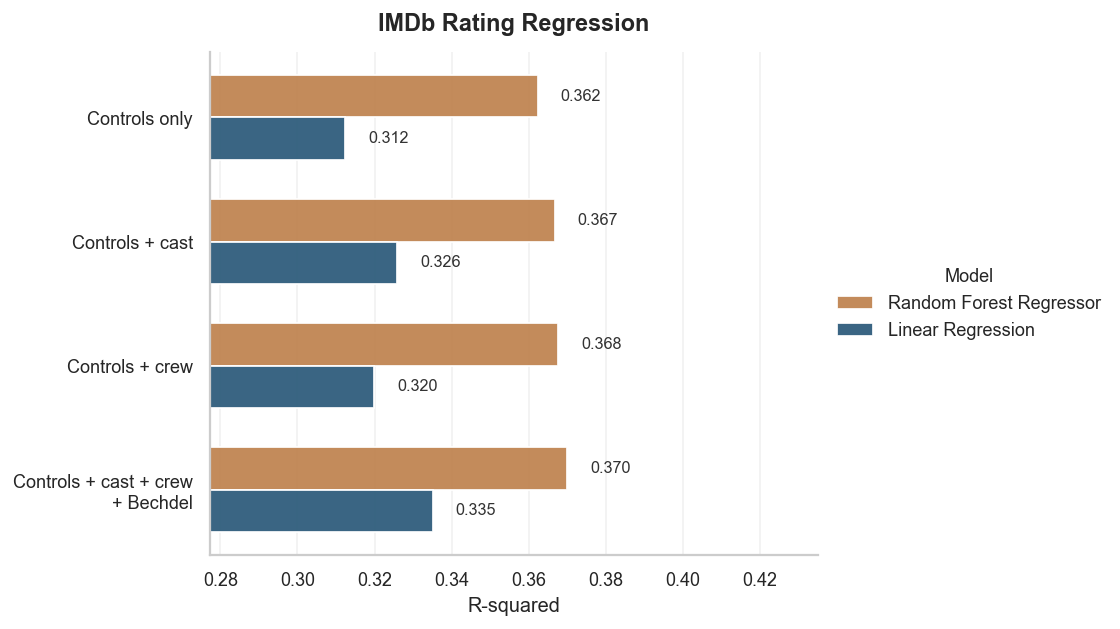

In [12]:
# Train regression models using IMDb rating as a continuous target.
imdb_regression_results, imdb_regression_models = evaluate_regression(
    imdb_df,
    target="imdbAverageRating",
    task_name="IMDb rating regression",
)

# Display MAE, RMSE, and R-squared for regression models.
display(imdb_regression_results)

# Plot R-squared values for regression model comparison.
plot_metric_dotplot(
    imdb_regression_results,
    title="IMDb Rating Regression",
    metric="r2",
    xlabel="R-squared",
)

## 9. Cast vs Crew Added Value

This section compares the added value of cast and crew representation features. For each task, the best controls-only model is used as the baseline, and ROC-AUC gain is calculated for the representation feature groups.

,Success metric,Representation model,Best model,ROC-AUC,Added value vs controls
0,High IMDb rating,cast,Logistic Regression,0.812,-0.004
1,High IMDb rating,crew,Random Forest,0.814,-0.002
2,High IMDb rating,cast + crew + Bechdel,Logistic Regression,0.814,-0.002
3,Profitability,cast,Random Forest,0.688,-0.003
4,Profitability,crew,Random Forest,0.696,0.005
5,Profitability,cast + crew + Bechdel,Random Forest,0.744,0.054
6,High popularity,cast,Random Forest,0.814,0.015
7,High popularity,crew,Logistic Regression,0.820,0.020
8,High popularity,cast + crew + Bechdel,Logistic Regression,0.845,0.046


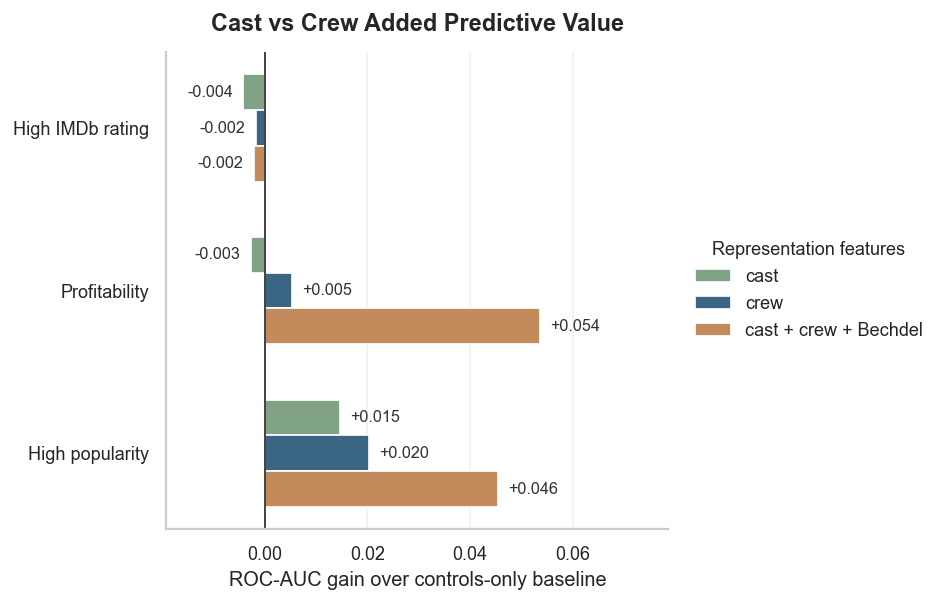

In [13]:
# Calculate added predictive value of representation feature groups over controls.
classification_result_tables = {
    "High IMDb rating": imdb_results,
    "Profitability": profit_results,
    "High popularity": popularity_results,
}

comparison_groups = [
    "Controls + cast",
    "Controls + crew",
    "Controls + cast + crew + Bechdel",
]

added_value_rows = []
for metric_name, results in classification_result_tables.items():
    # Use the best controls-only ROC-AUC score as the baseline.
    baseline_score = (
        results[results["feature_group"] == "Controls only"]
        .sort_values(["roc_auc", "f1"], ascending=False)
        .iloc[0]["roc_auc"]
    )

    # Calculate ROC-AUC gain for cast, crew, and full representation feature groups.
    for group in comparison_groups:
        group_best = (
            results[results["feature_group"] == group]
            .sort_values(["roc_auc", "f1"], ascending=False)
            .iloc[0]
        )
        added_value_rows.append({
            "Success metric": metric_name,
            "Representation model": group.replace("Controls + ", ""),
            "Best model": group_best["model"],
            "ROC-AUC": group_best["roc_auc"],
            "Added value vs controls": group_best["roc_auc"] - baseline_score,
        })

cast_crew_added_value = pd.DataFrame(added_value_rows)
display(cast_crew_added_value)

# Plot ROC-AUC gain for representation feature groups.
plot_data = cast_crew_added_value.copy()
model_order = ["cast", "crew", "cast + crew + Bechdel"]
metric_order = ["High IMDb rating", "Profitability", "High popularity"]
colors = {
    "cast": "#7A9E7E",
    "crew": "#2F5D7C",
    "cast + crew + Bechdel": "#C08552",
}

y_base = np.arange(len(metric_order))
bar_height = 0.22
offsets = np.linspace(-bar_height, bar_height, len(model_order))

fig, ax = plt.subplots(figsize=(9.6, 4.8))
for offset, representation_model in zip(offsets, model_order):
    subset = (
        plot_data[plot_data["Representation model"] == representation_model]
        .set_index("Success metric")
        .reindex(metric_order)
    )
    values = subset["Added value vs controls"].values
    positions = y_base + offset

    ax.barh(
        positions,
        values,
        height=bar_height,
        color=colors[representation_model],
        label=representation_model,
        alpha=0.95,
    )

    # Add ROC-AUC gain labels to the bars.
    for x, y in zip(values, positions):
        label = f"{x:+.3f}"
        x_text = x + 0.002 if x >= 0 else x - 0.002
        ha = "left" if x >= 0 else "right"
        ax.text(x_text, y, label, va="center", ha=ha, fontsize=9, color="#333333")

ax.axvline(0, color="#333333", linewidth=1)
ax.set_yticks(y_base)
ax.set_yticklabels(metric_order)
ax.invert_yaxis()
ax.set_title("Cast vs Crew Added Predictive Value", pad=12)
ax.set_xlabel("ROC-AUC gain over controls-only baseline")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.25)
ax.grid(axis="y", visible=False)
ax.legend(title="Representation features", frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5))
ax.set_xlim(
    min(-0.01, plot_data["Added value vs controls"].min() - 0.015),
    plot_data["Added value vs controls"].max() + 0.025,
)

plt.tight_layout(rect=[0, 0, 0.78, 1])
plt.show()

## 10. Model Summary

The main classification results are summarized side by side. The comparison focuses on ROC-AUC gain over the controls-only baseline.

,Success metric,Baseline model,Baseline score,Best model,Best feature group,Best score,Gain over baseline
0,High IMDb rating,Random Forest,0.816,Random Forest,Controls only,0.816,0.000
2,High popularity,Logistic Regression,0.799,Logistic Regression,Controls + cast + crew + Bechdel,0.845,0.046
1,Profitability,Random Forest,0.690,Random Forest,Controls + cast + crew + Bechdel,0.744,0.054


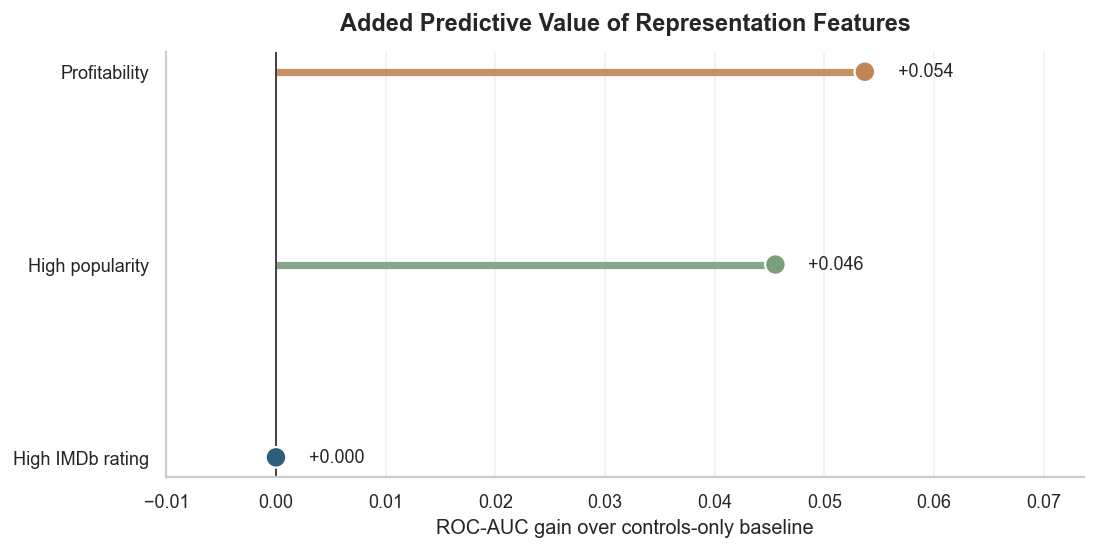

In [14]:
# Create a final summary table for the classification tasks.
summary = pd.DataFrame([
    {"Success metric": "High IMDb rating", **best_vs_baseline(imdb_results)},
    {"Success metric": "Profitability", **best_vs_baseline(profit_results)},
    {"Success metric": "High popularity", **best_vs_baseline(popularity_results)},
]).sort_values("Gain over baseline")

display(summary)

# Plot ROC-AUC gain from the full representation feature set by task.
fig, ax = plt.subplots(figsize=(8.6, 4.4))
colors = summary["Success metric"].map({
    "High IMDb rating": "#2F5D7C",
    "Profitability": "#C08552",
    "High popularity": "#7A9E7E",
})

ax.hlines(summary["Success metric"], 0, summary["Gain over baseline"], color=colors, linewidth=4, alpha=0.9)
ax.scatter(summary["Gain over baseline"], summary["Success metric"], color=colors, s=130, edgecolor="white", linewidth=1.2, zorder=3)
ax.axvline(0, color="#333333", linewidth=1)
ax.set_title("Added Predictive Value of Representation Features", pad=12)
ax.set_xlabel("ROC-AUC gain over controls-only baseline")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.25)
ax.grid(axis="y", visible=False)
ax.set_xlim(min(-0.005, summary["Gain over baseline"].min() - 0.01), summary["Gain over baseline"].max() + 0.02)

# Add ROC-AUC gain labels to plotted points.
for _, row in summary.iterrows():
    ax.text(row["Gain over baseline"] + 0.003, row["Success metric"], f"+{row['Gain over baseline']:.3f}", va="center", fontsize=10)

plt.tight_layout()
plt.show()

## 11. Interpretation

The machine learning results show that movie outcomes are shaped by multiple factors. Budget, genre, runtime, release period, language, and country remain important controls across tasks.

Cast and crew representation are evaluated separately because they capture different parts of gender representation. Cast variables describe women appearing on screen, while crew variables describe women in behind-camera roles.

For the high IMDb rating classification task, representation variables do not improve ROC-AUC over the controls-only baseline. In the regression check, the full representation feature set gives only a small improvement in R-squared, so the rating results are still mainly driven by general movie characteristics.

Profitability and popularity show clearer gains from representation variables. The strongest models for these outcomes use cast, crew, and Bechdel variables together with the control features.

Overall, female representation is not treated as a standalone determinant of movie success. The results indicate that representation variables can add predictive information for some outcomes when combined with standard movie metadata.